# NB13 — Vigor Temporal Structure: Affect and Model Parameters

**Two central questions, one unified temporal framework:**

1. **Affect → Vigor**: At which phases of a trial (onset, encounter, terminal) does subjective anxiety relate to pressing rate? 
2. **Model params → Vigor(t)**: When in trial time does each computational parameter (z, κ, β) shape pressing?

**Approach:**
- *Phase LMMs*: Linked anxiety probes (N≈5,000 probe-trial pairs) × 4 vigor phase metrics [onset_slope, onset_mean, enc_spike, term_mean]. All 4 DVs tested concurrently with FDR correction.
- *Functional regression*: At each 0.1s time bin across three alignment windows (trial-onset, encounter-aligned, terminal-aligned), fit LMM and extract β(t) coefficient — giving a time-resolved curve for each predictor.

**Alignment windows:**
- Onset: `t ∈ [0, 2.5s]` from trial start
- Encounter: `t_enc = t − encounterTime ∈ [−2, 2s]` (all trials — non-attack trials use scheduled encounter time)
- Terminal: `t_term = trialEndTime − t ∈ [0, 2.5s]` (counting backwards from trial end)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from sklearn.cross_decomposition import PLSRegression
from scipy import stats
import warnings
from pathlib import Path

BASE      = Path('/Users/nokada/Desktop/EffortForagingUnderThreat')
DATA      = BASE / 'data/exploratory_350/processed/stage5_filtered_data_20260317_094210'
VIGOR_DIR = BASE / 'data/exploratory_350/processed/vigor_processed'
STATS_DIR = BASE / 'results/stats'
FIG_DIR   = BASE / 'results/figures/vigor_temporal'
FIG_DIR.mkdir(parents=True, exist_ok=True)

def run_lmm(df, formula, groups='subj'):
    data = df.reset_index(drop=True)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        m = smf.mixedlm(formula, data=data, groups=data[groups])
        r = m.fit(reml=False, method='lbfgs')
    return r

print('Setup done.')

Setup done.


## 1. Load data and build probe-trial alignment

In [2]:
# ── Data ──────────────────────────────────────────────────────────────────────
feel = pd.read_csv(DATA / 'feelings.csv').rename(columns={
    'attackingProb':'p_threat','questionLabel':'affect_type','response':'rating',
    'trialNumber':'event_idx','distanceFromSafety':'dist_safety','distance':'dist_level'
})
ptm = pd.read_parquet(VIGOR_DIR / 'phase_trial_metrics.parquet')
svt = pd.read_parquet(VIGOR_DIR / 'smoothed_vigor_ts.parquet')

# Parameters
z_df = pd.read_csv(STATS_DIR / 'FET_Exp_Bias_z_params.csv')[['subject','mean']].rename(columns={'subject':'subj','mean':'z'})
k_df = pd.read_csv(STATS_DIR / 'FET_Exp_Bias_k_params.csv')[['subject','mean']].rename(columns={'subject':'subj','mean':'kappa'})
b_df = pd.read_csv(STATS_DIR / 'FET_Exp_Bias_beta_params.csv')[['subject','mean']].rename(columns={'subject':'subj','mean':'beta_param'})
params = z_df.merge(k_df,on='subj').merge(b_df,on='subj')
for c in ['z','kappa','beta_param']:
    params[f'{c}_z'] = (params[c] - params[c].mean()) / params[c].std()

print(f'svt: {len(svt):,} rows | ptm: {len(ptm):,} rows | params: {len(params)} subjects')

# ── Probe-to-behavioral-trial alignment ───────────────────────────────────────
MAX_EVENT = 80
linked_rows = []
for subj_id, feel_s in feel.groupby('subj'):
    probe_idx = set(feel_s['event_idx'].unique())
    beh_idx   = sorted(set(range(MAX_EVENT + 1)) - probe_idx)
    ptm_s     = ptm[ptm['subj'] == subj_id].set_index('trial')

    for _, row in feel_s.iterrows():
        e = row['event_idx']
        preceding = [b for b in beh_idx if b < e]
        following = [b for b in beh_idx if b > e]
        pre_e = preceding[-1] if preceding else None
        fol_e = following[0]  if following else None

        linked = row.to_dict()
        linked['pre_trial_event'] = pre_e
        linked['fol_trial_event'] = fol_e

        for prefix, ev in [('pre', pre_e), ('fol', fol_e)]:
            cols = ['onset_slope','onset_mean','enc_spike','term_mean','term_slope',
                    'threat','effort_H','outcome','isAttackTrial']
            if ev is not None and ev in ptm_s.index:
                for col in cols:
                    linked[f'{prefix}_{col}'] = ptm_s.loc[ev, col] if col in ptm_s.columns else np.nan
            else:
                for col in cols:
                    linked[f'{prefix}_{col}'] = np.nan
        linked_rows.append(linked)

linked = pd.DataFrame(linked_rows)
anx = linked[linked['affect_type']=='anxiety'].copy()
conf = linked[linked['affect_type']=='confidence'].copy()

print(f'Linked: {len(anx):,} anxiety, {len(conf):,} confidence probes')
print(f'With preceding trial: {anx["pre_onset_slope"].notna().sum()} anxiety probes')

svt: 3,988,277 rows | ptm: 23,556 rows | params: 293 subjects


Linked: 5,274 anxiety, 5,272 confidence probes
With preceding trial: 5000 anxiety probes


## 2. Phase-specific LMMs: affect → each vigor phase

Test whether anxiety (and confidence) predict each vigor phase metric separately:
- **Onset slope**: anticipatory mobilization rate  
- **Onset mean**: average pressing in first 2s  
- **Encounter spike**: phasic encounter response  
- **Terminal mean**: final pressing before trial end

For each: M1 = raw anxiety + threat; M2 = residual anxiety (beyond threat) + threat.
FDR correct across all 4 phases × 2 affect types × 2 models = 16 key tests.

In [3]:
# ── Prepare combined phase dataset ────────────────────────────────────────────
VIGOR_PHASES = ['onset_slope','onset_mean','enc_spike','term_mean']

all_phase_results = []

for af_type, df_af in [('anxiety', anx), ('confidence', conf)]:
    df_work = df_af.dropna(subset=['rating','pre_threat','dist_safety'] + [f'pre_{v}' for v in VIGOR_PHASES]).copy()
    df_work = df_work.reset_index(drop=True)

    # Z-score predictors
    for col in ['rating','pre_threat','dist_safety']:
        df_work[f'{col}_z'] = (df_work[col] - df_work[col].mean()) / df_work[col].std()

    # Residual affect (beyond threat + distance) — fix index alignment
    res_model = run_lmm(df_work, 'rating ~ pre_threat_z + dist_safety_z')
    df_work['anx_resid'] = res_model.resid.values  # .values strips index
    df_work['anx_resid_z'] = (df_work['anx_resid'] - df_work['anx_resid'].mean()) / df_work['anx_resid'].std()

    sep = '=' * 60
    print(f'\n{sep}')
    print(f'  {af_type.upper()} (N={len(df_work):,} probe-trial pairs)')
    print(sep)
    print(f'  {"Phase":15s}  {"M1 β(raw)":>12s}  {"p":>7s}  {"M2 β(resid)":>12s}  {"p":>7s}')
    print(f'  {"-"*58}')

    for phase in VIGOR_PHASES:
        dv = f'pre_{phase}'
        df_work[f'{dv}_z'] = (df_work[dv] - df_work[dv].mean()) / df_work[dv].std()

        # M1: raw affect + threat
        try:
            r1 = run_lmm(df_work, f'{dv}_z ~ rating_z + pre_threat_z')
            b1 = r1.params.get('rating_z', np.nan)
            p1 = r1.pvalues.get('rating_z', np.nan)
        except Exception:
            b1, p1 = np.nan, np.nan

        # M2: residual affect + threat
        try:
            r2 = run_lmm(df_work, f'{dv}_z ~ anx_resid_z + pre_threat_z')
            b2 = r2.params.get('anx_resid_z', np.nan)
            p2 = r2.pvalues.get('anx_resid_z', np.nan)
        except Exception:
            b2, p2 = np.nan, np.nan

        print(f'  {phase:15s}  β={b1:+.3f} p={p1:.4f}  β={b2:+.3f} p={p2:.4f}')
        all_phase_results.append({'affect':af_type,'phase':phase,'model':'M1_raw','beta':b1,'p':p1,'n':len(df_work)})
        all_phase_results.append({'affect':af_type,'phase':phase,'model':'M2_resid','beta':b2,'p':p2,'n':len(df_work)})

phase_df = pd.DataFrame(all_phase_results)
_, p_fdr, _, _ = multipletests(phase_df['p'].fillna(1), method='fdr_bh')
phase_df['p_fdr'] = p_fdr
phase_df['sig'] = phase_df['p_fdr'] < 0.05

print('\n--- FDR-corrected summary ---')
for _, row in phase_df.dropna(subset=['beta']).sort_values('p').iterrows():
    sig = ' ***' if row['p_fdr']<0.001 else (' **' if row['p_fdr']<0.01 else (' *' if row['p_fdr']<0.05 else ' n.s.'))
    print(f"  [{row['affect']:10s}][{row['model']:8s}] {row['phase']:15s} β={row['beta']:+.3f} p_fdr={row['p_fdr']:.4f}{sig}")



  ANXIETY (N=3,123 probe-trial pairs)
  Phase               M1 β(raw)        p   M2 β(resid)        p
  ----------------------------------------------------------


  onset_slope      β=-0.005 p=0.7281  β=-0.006 p=0.6220


  onset_mean       β=+0.002 p=0.8778  β=+0.005 p=0.5749


  enc_spike        β=-0.009 p=0.6360  β=-0.018 p=0.2328
  term_mean        β=+0.008 p=0.6189  β=+0.002 p=0.8509



  CONFIDENCE (N=3,277 probe-trial pairs)
  Phase               M1 β(raw)        p   M2 β(resid)        p
  ----------------------------------------------------------


  onset_slope      β=-0.019 p=0.2419  β=-0.014 p=0.2907


  onset_mean       β=+0.013 p=0.2947  β=+0.011 p=0.2837


  enc_spike        β=-0.033 p=0.0627  β=-0.026 p=0.0924


  term_mean        β=+0.006 p=0.7447  β=+0.008 p=0.6181

--- FDR-corrected summary ---
  [confidence][M1_raw  ] enc_spike       β=-0.033 p_fdr=0.6736 n.s.
  [confidence][M2_resid] enc_spike       β=-0.026 p_fdr=0.6736 n.s.
  [anxiety   ][M2_resid] enc_spike       β=-0.018 p_fdr=0.6736 n.s.
  [confidence][M1_raw  ] onset_slope     β=-0.019 p_fdr=0.6736 n.s.
  [confidence][M2_resid] onset_mean      β=+0.011 p_fdr=0.6736 n.s.
  [confidence][M2_resid] onset_slope     β=-0.014 p_fdr=0.6736 n.s.
  [confidence][M1_raw  ] onset_mean      β=+0.013 p_fdr=0.6736 n.s.
  [anxiety   ][M2_resid] onset_mean      β=+0.005 p_fdr=0.8480 n.s.
  [confidence][M2_resid] term_mean       β=+0.008 p_fdr=0.8480 n.s.
  [anxiety   ][M1_raw  ] term_mean       β=+0.008 p_fdr=0.8480 n.s.
  [anxiety   ][M2_resid] onset_slope     β=-0.006 p_fdr=0.8480 n.s.
  [anxiety   ][M1_raw  ] enc_spike       β=-0.009 p_fdr=0.8480 n.s.
  [anxiety   ][M1_raw  ] onset_slope     β=-0.005 p_fdr=0.8511 n.s.
  [confidence][M1_raw  ] term

## 3. PLS regression: affect profile → vigor phase profile

Rather than test each DV separately, PLS finds the linear combination of vigor phases  
(Y) most covarying with the affect profile (X). This gives a single compressed answer:  
*what pattern of across-phase vigor is most associated with anxiety + confidence?*

X = [anxiety_z, confidence_z] (per probe pair — trials where both probes match)  
Y = [onset_slope_z, onset_mean_z, enc_spike_z, term_mean_z] (preceding trial)

In [4]:
# PLS: use subject-level means (affect profile × vigor profile), N=293
# Compute mean task anxiety/confidence per subject from linked probes
subj_anx_means = anx.dropna(subset=['rating']).groupby('subj').agg(
    mean_task_anx=('rating','mean'),
    **{f'mean_{v}': (f'pre_{v}', 'mean') for v in VIGOR_PHASES}
).reset_index().dropna()

subj_conf_means = conf.dropna(subset=['rating']).groupby('subj')['rating'].mean().reset_index()
subj_conf_means.columns = ['subj','mean_task_conf']

subj_pls = subj_anx_means.merge(subj_conf_means, on='subj').dropna()
print(f'PLS subject-level dataset: N={len(subj_pls)}')

# Z-score
affect_cols = ['mean_task_anx','mean_task_conf']
vigor_cols  = [f'mean_{v}' for v in VIGOR_PHASES]
for c in affect_cols + vigor_cols:
    subj_pls[f'{c}_z'] = (subj_pls[c] - subj_pls[c].mean()) / subj_pls[c].std()

X = subj_pls[[f'{c}_z' for c in affect_cols]].values
Y = subj_pls[[f'{c}_z' for c in vigor_cols]].values
print(f'PLS: X={X.shape}, Y={Y.shape}')

# PLS regression (1 component)
pls = PLSRegression(n_components=1, scale=False)
pls.fit(X, Y)

# Cross-validated R² (leave-one-out)
from sklearn.model_selection import cross_val_score
cv_r2 = cross_val_score(PLSRegression(n_components=1, scale=False), X, Y, cv=10, scoring='r2')
print(f'PLS 10-fold CV R²: {cv_r2.mean():.3f} (SD={cv_r2.std():.3f})')

# Permutation test
np.random.seed(42)
r_obs = np.corrcoef(pls.x_scores_[:,0], pls.y_scores_[:,0])[0,1]
r_perm = []
for _ in range(1000):
    pls_p = PLSRegression(n_components=1, scale=False)
    pls_p.fit(X[np.random.permutation(len(X))], Y)
    r_perm.append(np.corrcoef(pls_p.x_scores_[:,0], pls_p.y_scores_[:,0])[0,1])
p_pls = np.mean(np.abs(r_perm) >= np.abs(r_obs))
print(f'PLS Component 1: r_obs={r_obs:.3f} (X-Y score correlation), p_perm={p_pls:.3f}')

print('\nX loadings:')
for feat, load in zip(['Mean task anxiety','Mean task confidence'], pls.x_loadings_[:,0]):
    print(f'  {feat:22s}: {load:+.3f}')
print('\nY loadings (vigor phases):')
for feat, load in zip(VIGOR_PHASES, pls.y_loadings_[:,0]):
    print(f'  {feat:15s}: {load:+.3f}')


PLS subject-level dataset: N=281
PLS: X=(281, 2), Y=(281, 4)
PLS 10-fold CV R²: -0.071 (SD=0.058)


PLS Component 1: r_obs=0.196 (X-Y score correlation), p_perm=0.033

X loadings:
  Mean task anxiety     : +0.890
  Mean task confidence  : -0.457

Y loadings (vigor phases):
  onset_slope    : +0.023
  onset_mean     : -0.165
  enc_spike      : +0.137
  term_mean      : +0.058


## 4. Functional regression: model params → vigor(t)

At each 0.1s time bin in the onset window [0, 2.5s] and encounter window [−2, 2s],  
fit LMM: `vigor_resid ~ z_z + kappa_z + beta_z + threat_c + (1|subj)`  
and extract β_z(t), β_κ(t), β_β(t).

This gives a time-resolved picture of *when* each computational parameter shapes pressing.  
`vigor_resid` (demand-normalized) isolates individual differences from task difficulty.

In [5]:
# Merge params with full timeseries
svt_p = svt.merge(params[['subj','z_z','kappa_z','beta_param_z']], on='subj', how='left')
svt_p = svt_p.rename(columns={'beta_param_z':'beta_z'})

# Threat: center at mean for LMM
svt_p['threat_c'] = svt_p['threat'] - svt_p['threat'].mean()

# Onset window: t ∈ [0, 2.5], binned at 0.1s resolution
ONSET_BINS = np.arange(0, 2.55, 0.1)
svt_p['t_bin_onset'] = pd.cut(svt_p['t'], bins=ONSET_BINS, labels=False, right=False)

# Encounter window: t_enc = t - encounterTime ∈ [-2, 2]
svt_p['t_enc'] = svt_p['t'] - svt_p['encounterTime']
ENC_BINS = np.arange(-2.0, 2.05, 0.1)
svt_p['t_bin_enc'] = pd.cut(svt_p['t_enc'], bins=ENC_BINS, labels=False, right=False)

# Terminal window: t_term = trialEndTime - t ∈ [0, 2.5] (counting back from end)
svt_p['t_term'] = svt_p['trialEndTime'] - svt_p['t']
TERM_BINS = np.arange(0, 2.55, 0.1)
svt_p['t_bin_term'] = pd.cut(svt_p['t_term'], bins=TERM_BINS, labels=False, right=False)

print(f'svt with params: {len(svt_p):,} rows')
print(f't_enc range: {svt_p["t_enc"].min():.1f} to {svt_p["t_enc"].max():.1f}')

def functional_lmm(df, dv, predictor_cols, group_col, bin_col, bin_range, label=''):
    """Run LMM at each time bin; return β and p for each predictor × bin."""
    results = {p: {'beta':[], 'p':[], 'bin_mid':[]} for p in predictor_cols}
    for b in range(bin_range):
        chunk = df[df[bin_col] == b].dropna(subset=[dv] + predictor_cols)
        if len(chunk) < 50 or chunk[group_col].nunique() < 20:
            for p in predictor_cols:
                results[p]['beta'].append(np.nan)
                results[p]['p'].append(np.nan)
                results[p]['bin_mid'].append(np.nan)
            continue
        try:
            formula = f'{dv} ~ ' + ' + '.join(predictor_cols)
            fit = run_lmm(chunk, formula, groups=group_col)
            mid = chunk[bin_col.replace('bin_','')].mean() if False else b  # use bin index
            for p in predictor_cols:
                results[p]['beta'].append(fit.params.get(p, np.nan))
                results[p]['p'].append(fit.pvalues.get(p, np.nan))
                results[p]['bin_mid'].append(b)
        except Exception:
            for p in predictor_cols:
                results[p]['beta'].append(np.nan)
                results[p]['p'].append(np.nan)
                results[p]['bin_mid'].append(b)
    return results

PARAMS = ['z_z','kappa_z','beta_z','threat_c']
PARAM_COLORS = {'z_z':'#2196F3','kappa_z':'#F44336','beta_z':'#FF9800','threat_c':'#9E9E9E'}
PARAM_LABELS = {'z_z':'z (hazard sensitivity)','kappa_z':'κ (effort discounting)',
                'beta_z':'β (threat bias)','threat_c':'threat (group level)'}

print('Running functional LMM — onset window...')
onset_res = functional_lmm(
    svt_p.dropna(subset=['t_bin_onset']),
    'vigor_resid', PARAMS, 'subj', 't_bin_onset', len(ONSET_BINS)-1
)
print('Running functional LMM — encounter window...')
enc_res = functional_lmm(
    svt_p.dropna(subset=['t_bin_enc']),
    'vigor_resid', PARAMS, 'subj', 't_bin_enc', len(ENC_BINS)-1
)
print('Running functional LMM — terminal window...')
term_res = functional_lmm(
    svt_p.dropna(subset=['t_bin_term']),
    'vigor_resid', PARAMS, 'subj', 't_bin_term', len(TERM_BINS)-1
)
print('Done.')

svt with params: 3,988,277 rows
t_enc range: -5.0 to 30.7
Running functional LMM — onset window...


Running functional LMM — encounter window...


Running functional LMM — terminal window...


Done.


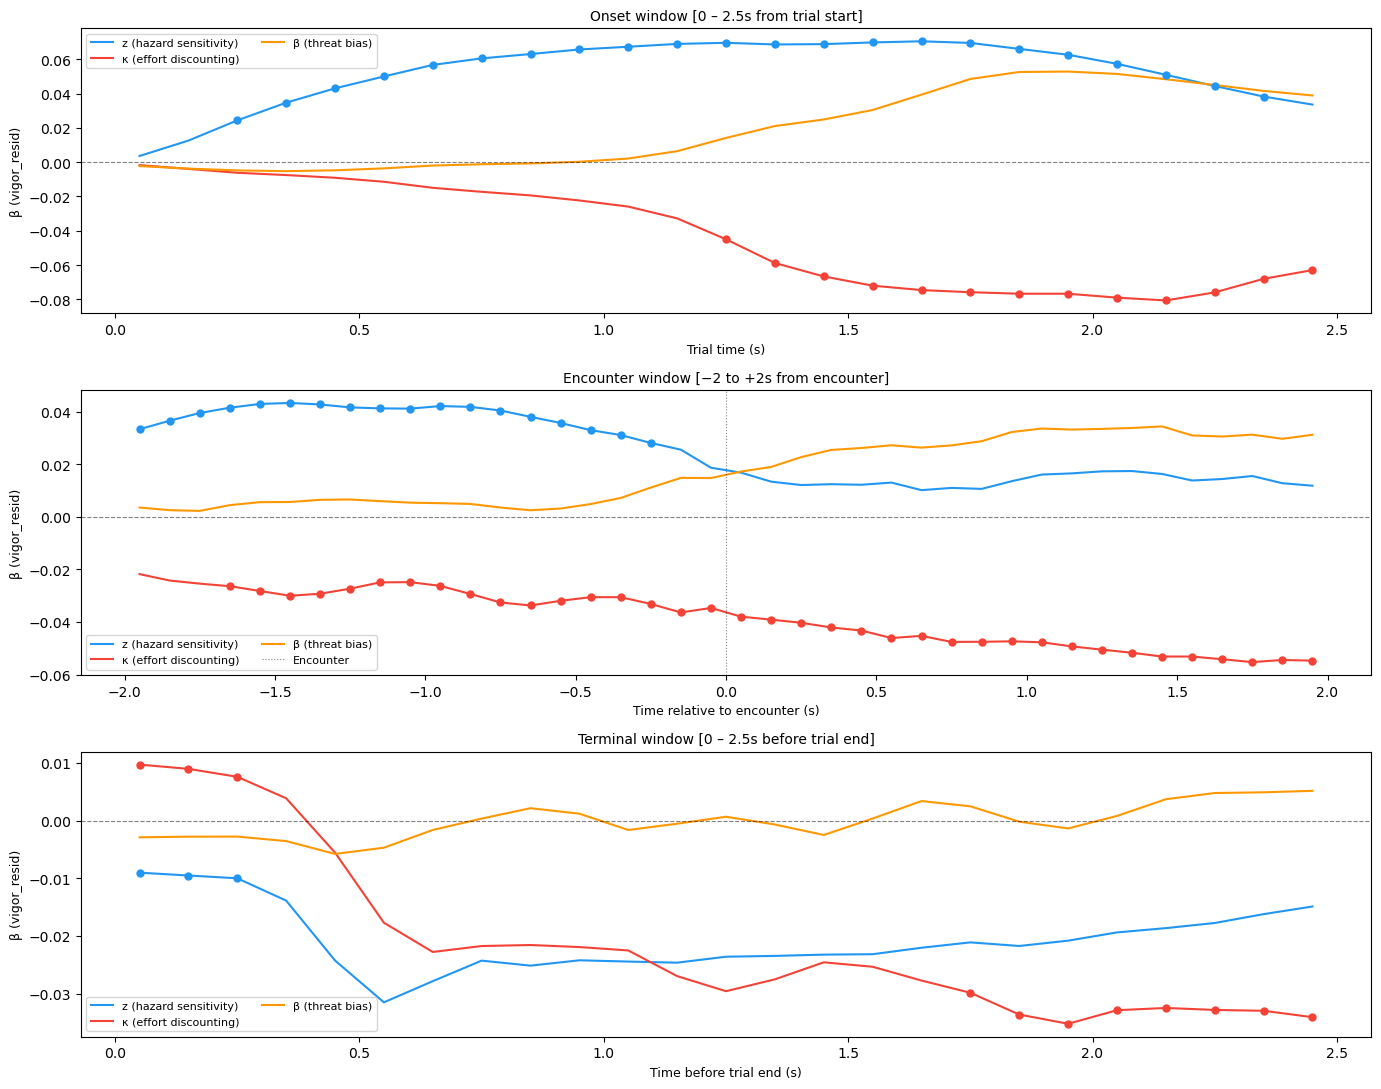

In [6]:
# Plot functional regression: model params → vigor(t)
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=False)

WINDOWS = [
    ('Onset window [0 – 2.5s from trial start]', onset_res, ONSET_BINS, 'Trial time (s)'),
    ('Encounter window [−2 to +2s from encounter]', enc_res, ENC_BINS, 'Time relative to encounter (s)'),
    ('Terminal window [0 – 2.5s before trial end]', term_res, TERM_BINS, 'Time before trial end (s)'),
]

for ax, (title, res_dict, bins, xlabel) in zip(axes, WINDOWS):
    n_bins = len(bins) - 1
    bin_mids = (bins[:-1] + bins[1:]) / 2

    for param in ['z_z','kappa_z','beta_z']:
        betas = np.array(res_dict[param]['beta'])
        ps    = np.array(res_dict[param]['p'])
        # FDR correct across bins for this param
        valid = ~np.isnan(ps)
        if valid.sum() > 1:
            _, ps_fdr, _, _ = multipletests(ps[valid], method='fdr_bh')
            ps_corrected = np.full(len(ps), np.nan)
            ps_corrected[valid] = ps_fdr
        else:
            ps_corrected = ps

        color = PARAM_COLORS[param]
        ax.plot(bin_mids[:len(betas)], betas, color=color, lw=1.5, label=PARAM_LABELS[param])
        # Mark significant bins
        sig_mask = ps_corrected < 0.05
        sig_x = bin_mids[:len(betas)][sig_mask[:len(bin_mids)]]
        sig_y = betas[sig_mask[:len(betas)]]
        ax.scatter(sig_x, sig_y, color=color, s=25, zorder=5, marker='o')

    ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
    if 'encounter' in title.lower():
        ax.axvline(0, color='k', lw=0.8, ls=':', alpha=0.5, label='Encounter')
    ax.set_ylabel('β (vigor_resid)', fontsize=9)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig(FIG_DIR / 'A_param_vigor_functional.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Functional regression: anxiety → vigor(t)

In [7]:
# Merge probe anxiety ratings with the timeseries of the preceding trial
# (subj, pre_trial_event) → look up all svt rows with (subj, trial==pre_trial_event)
anx_clean = anx.dropna(subset=['rating','pre_threat']).copy()
anx_clean['anx_z'] = (anx_clean['rating'] - anx_clean['rating'].mean()) / anx_clean['rating'].std()
anx_clean['threat_pre_z'] = (anx_clean['pre_threat'] - anx_clean['pre_threat'].mean()) / anx_clean['pre_threat'].std()

# Also get residual anxiety
res_fit = run_lmm(anx_clean.dropna(subset=['dist_safety']).assign(
    dist_z=lambda d: (d['dist_safety']-d['dist_safety'].mean())/d['dist_safety'].std()
), 'rating ~ threat_pre_z + dist_z')
anx_clean2 = anx_clean.dropna(subset=['dist_safety']).copy()
anx_clean2['anx_resid'] = res_fit.resid
anx_clean2['anx_resid_z'] = (anx_clean2['anx_resid'] - anx_clean2['anx_resid'].mean()) / anx_clean2['anx_resid'].std()

# Build svt slice keyed by (subj, trial=pre_trial_event)
svt_cols = ['subj','trial','t','t_enc','t_term','vigor_norm','vigor_resid','t_bin_onset','t_bin_enc','t_bin_term']
svt_slim = svt_p[svt_cols].copy()

# Merge: anx_clean2 has (subj, pre_trial_event); svt_slim has (subj, trial)
anx_svt = svt_slim.merge(
    anx_clean2[['subj','pre_trial_event','anx_z','anx_resid_z','threat_pre_z']].rename(
        columns={'pre_trial_event':'trial'}),
    on=['subj','trial'], how='inner'
)
print(f'Affect-timeseries merged: {len(anx_svt):,} rows, {anx_svt["subj"].nunique()} subjects')

# Run functional LMM: affect → vigor at each time bin
print('Running affect functional LMM — onset...')
anx_onset_res = functional_lmm(
    anx_svt.dropna(subset=['t_bin_onset']),
    'vigor_resid', ['anx_z','threat_pre_z'], 'subj', 't_bin_onset', len(ONSET_BINS)-1
)
print('Running affect functional LMM — encounter...')
anx_enc_res = functional_lmm(
    anx_svt.dropna(subset=['t_bin_enc']),
    'vigor_resid', ['anx_z','threat_pre_z'], 'subj', 't_bin_enc', len(ENC_BINS)-1
)
print('Running affect functional LMM — terminal...')
anx_term_res = functional_lmm(
    anx_svt.dropna(subset=['t_bin_term']),
    'vigor_resid', ['anx_z','threat_pre_z'], 'subj', 't_bin_term', len(TERM_BINS)-1
)
print('Done.')

Affect-timeseries merged: 789,483 rows, 293 subjects
Running affect functional LMM — onset...


Running affect functional LMM — encounter...


Running affect functional LMM — terminal...


Done.


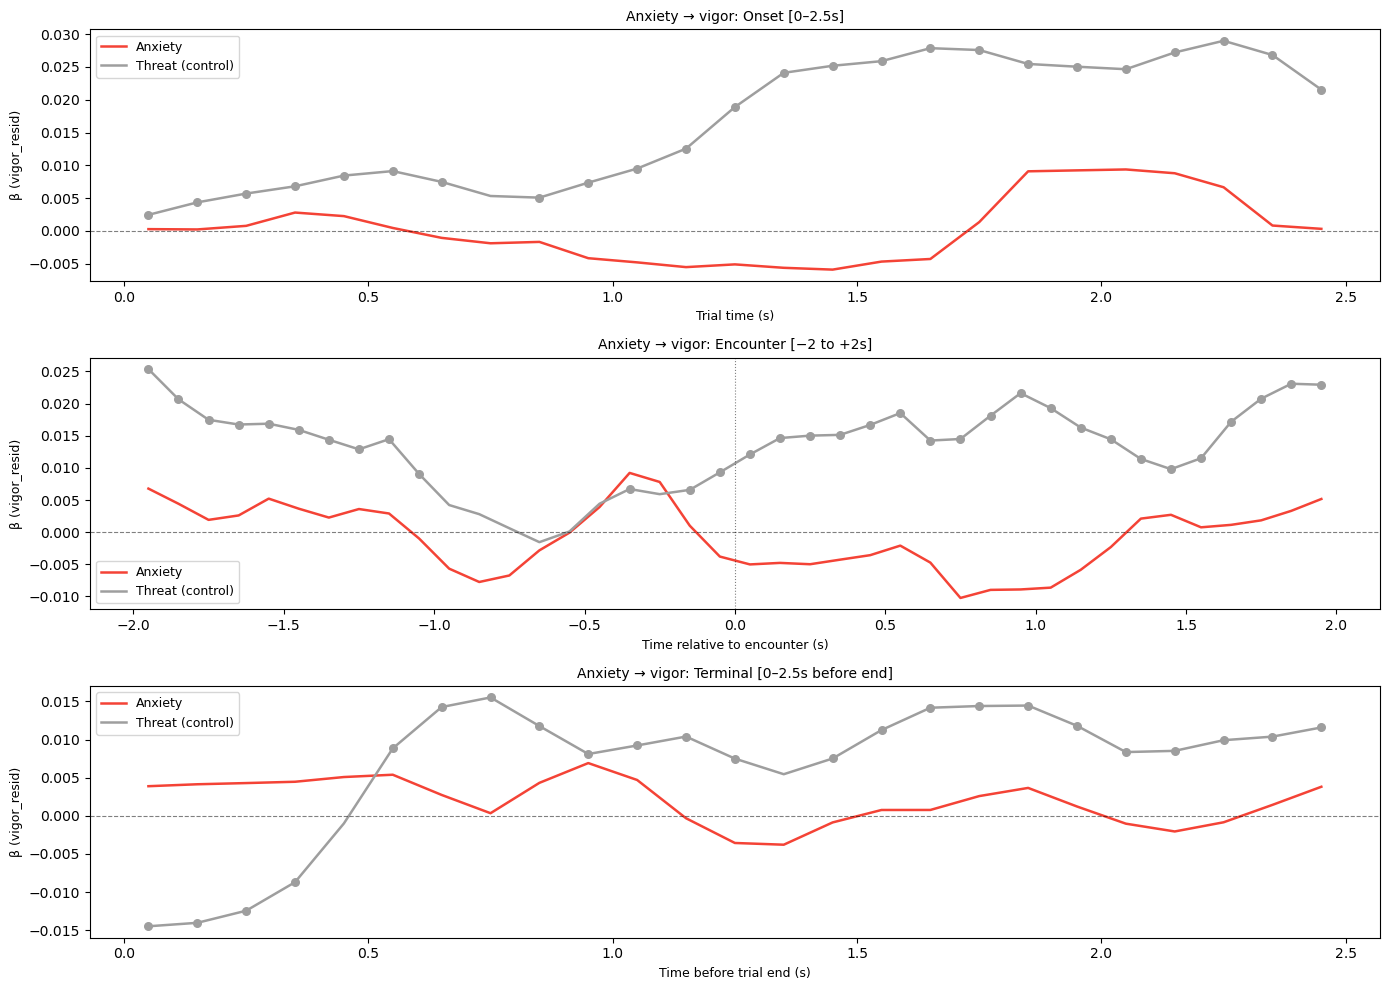

In [8]:
# Plot: anxiety → vigor(t) across all three windows
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

WINDOWS_ANX = [
    ('Onset [0–2.5s]', anx_onset_res, ONSET_BINS, 'Trial time (s)'),
    ('Encounter [−2 to +2s]', anx_enc_res, ENC_BINS, 'Time relative to encounter (s)'),
    ('Terminal [0–2.5s before end]', anx_term_res, TERM_BINS, 'Time before trial end (s)'),
]

for ax, (title, res_dict, bins, xlabel) in zip(axes, WINDOWS_ANX):
    bin_mids = (bins[:-1] + bins[1:]) / 2
    n_bins = len(bin_mids)

    for predictor, color, label in [
        ('anx_z', '#F44336', 'Anxiety'),
        ('threat_pre_z', '#9E9E9E', 'Threat (control)'),
    ]:
        betas = np.array(res_dict[predictor]['beta'])
        ps    = np.array(res_dict[predictor]['p'])
        valid = ~np.isnan(ps)
        if valid.sum() > 1:
            _, ps_fdr, _, _ = multipletests(ps[valid], method='fdr_bh')
            ps_corr = np.full(len(ps), np.nan)
            ps_corr[valid] = ps_fdr
        else:
            ps_corr = ps

        ax.plot(bin_mids[:len(betas)], betas, color=color, lw=1.8, label=label)
        sig_mask = (ps_corr < 0.05)
        sig_x = bin_mids[:len(betas)][sig_mask[:n_bins]]
        sig_y = betas[sig_mask[:len(betas)]]
        ax.scatter(sig_x, sig_y, color=color, s=30, zorder=5)

    ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
    if 'Encounter' in title:
        ax.axvline(0, color='k', lw=0.8, ls=':', alpha=0.5)
    ax.set_ylabel('β (vigor_resid)', fontsize=9)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_title(f'Anxiety → vigor: {title}', fontsize=10)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'B_anxiety_vigor_functional.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Save results

In [9]:
# Save phase results
phase_df.to_csv(STATS_DIR / 'vigor_affect_phase_lmm.csv', index=False)
print(f'Saved: {STATS_DIR / "vigor_affect_phase_lmm.csv"}')

# Save functional regression results (params)
func_rows = []
for window_name, res_dict, bins in [
    ('onset', onset_res, ONSET_BINS),
    ('encounter', enc_res, ENC_BINS),
    ('terminal', term_res, TERM_BINS),
]:
    bin_mids = (bins[:-1] + bins[1:]) / 2
    for param, res in res_dict.items():
        for i, (b, p) in enumerate(zip(res['beta'], res['p'])):
            func_rows.append({'window':window_name,'predictor':param,
                              'bin':i,'bin_mid':bin_mids[i] if i<len(bin_mids) else np.nan,
                              'beta':b,'p':p})
func_df = pd.DataFrame(func_rows)
func_df.to_csv(STATS_DIR / 'vigor_param_functional.csv', index=False)
print(f'Saved: {STATS_DIR / "vigor_param_functional.csv"}')

# Save functional affect results
anx_func_rows = []
for window_name, res_dict, bins in [
    ('onset', anx_onset_res, ONSET_BINS),
    ('encounter', anx_enc_res, ENC_BINS),
    ('terminal', anx_term_res, TERM_BINS),
]:
    bin_mids = (bins[:-1] + bins[1:]) / 2
    for param, res in res_dict.items():
        for i, (b, p) in enumerate(zip(res['beta'], res['p'])):
            anx_func_rows.append({'window':window_name,'predictor':param,
                                   'bin':i,'bin_mid':bin_mids[i] if i<len(bin_mids) else np.nan,
                                   'beta':b,'p':p})
anx_func_df = pd.DataFrame(anx_func_rows)
anx_func_df.to_csv(STATS_DIR / 'vigor_anxiety_functional.csv', index=False)
print(f'Saved: {STATS_DIR / "vigor_anxiety_functional.csv"}')

print()
print('=== PHASE SUMMARY (FDR-corrected) ===')
sig_phase = phase_df[phase_df['sig']].sort_values('p_fdr')
if len(sig_phase) == 0:
    print('No phase-level affect → vigor effects survive FDR correction.')
else:
    for _, r in sig_phase.iterrows():
        sig_str = '***' if r['p_fdr']<0.001 else ('**' if r['p_fdr']<0.01 else '*')
        print(f"  [{r['affect']:10s}][{r['model']:8s}] {r['phase']:15s} β={r['beta']:+.3f} p_fdr={r['p_fdr']:.4f} {sig_str}")

Saved: /Users/nokada/Desktop/EffortForagingUnderThreat/results/stats/vigor_affect_phase_lmm.csv
Saved: /Users/nokada/Desktop/EffortForagingUnderThreat/results/stats/vigor_param_functional.csv
Saved: /Users/nokada/Desktop/EffortForagingUnderThreat/results/stats/vigor_anxiety_functional.csv

=== PHASE SUMMARY (FDR-corrected) ===
No phase-level affect → vigor effects survive FDR correction.
